<a href="https://colab.research.google.com/github/SlowNCalm/Target-Corp-Sales-Regression-Model/blob/main/regressionAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Target Corp Sales Regression Model
# Made by Jackie Chen

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = "{:.2f}".format

In [ ]:
df = pd.read_csv('qSales_2024.csv')

In [ ]:
TARGETCORPSales = df.loc[df["conm"]=="TARGET CORP"].copy()

In [ ]:
display(TARGETCORPSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


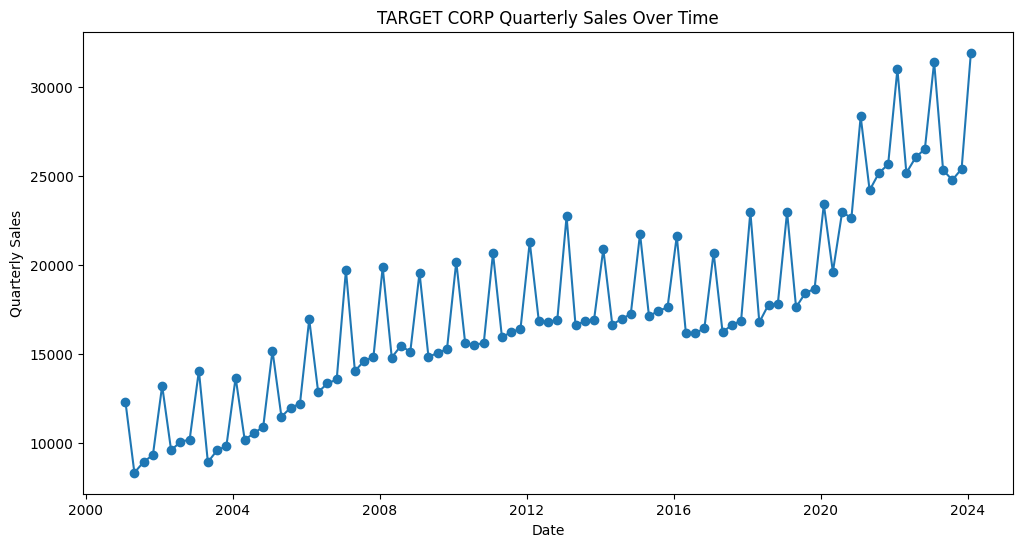

In [ ]:
TARGETCORPSales['datadate'] = pd.to_datetime(TARGETCORPSales['datadate'])

plt.figure(figsize=(12, 6))
plt.plot(TARGETCORPSales['datadate'], TARGETCORPSales['saleq'], marker='o', linestyle='-')

plt.title('TARGET CORP Quarterly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Quarterly Sales')


plt.show()

In [ ]:
# create a new column called time, and it will be our independent variable

TARGETCORPSales["time"] = range(1, len(TARGETCORPSales) + 1)
display(TARGETCORPSales.head())
display(TARGETCORPSales.tail())

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92
184,3813,2024-01-31,2023,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q4,2023Q4,31919.00,A,93


In [ ]:
# create a regression model using time as the independent variable
# 1. Split the data into training and testing - our job to split 75:25 ; use a different split when specified, and overall through time and experience

# The following code tells python to take the first 75% of rows
dt4training = TARGETCORPSales[:int(0.75*len(TARGETCORPSales))]
# The following code tells python to take the rest of the rows
dt4testing = TARGETCORPSales[int(0.75*len(TARGETCORPSales)):]

In [ ]:
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q1,2018Q1,16781.00,A,70
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q2,2018Q2,17777.00,A,71
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q3,2018Q3,17821.00,A,72
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q4,2018Q4,22977.00,A,73
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q1,2019Q1,17627.00,A,74
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q2,2019Q2,18422.00,A,75
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q3,2019Q3,18664.00,A,76
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q4,2019Q4,23399.00,A,77
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q1,2020Q1,19615.00,A,78
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q2,2020Q2,22975.00,A,79


In [ ]:
display(dt4training)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,3813,2017-01-31,2016,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2016Q4,2016Q4,20690.00,A,65
157,3813,2017-04-30,2017,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q1,2017Q1,16223.00,A,66
158,3813,2017-07-31,2017,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q2,2017Q2,16634.00,A,67
159,3813,2017-10-31,2017,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q3,2017Q3,16874.00,A,68


In [ ]:
x = dt4training.loc[:,"time"]
x = sm.add_constant(x)

y = dt4training.loc[:,"saleq"]

model1 = sm.OLS(y, x).fit()

model1.params


,0
const,10503.75
time,139.30


In [ ]:
x_test = dt4testing.loc[:,"time"]
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
161,20254.51
162,20393.81
163,20533.11
164,20672.40
165,20811.70
166,20951.00
167,21090.29
168,21229.59
169,21368.89
170,21508.18


In [ ]:
# to get a range of values its 2 step
# 1. use the get)prediction function from our model
# 2. Get the summary frame of the prediction using a confidence level

prediction_results = model1.get_prediction(x_test)
prediction_results.summary_frame(alpha=0.2) # this is an 80% confidence interval

# key numbers to look at are the obs_ci_lower and obs_ci_upper

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,20254.51,572.33,19513.74,20995.29,17122.35,23386.68
162,20393.81,584.73,19636.99,21150.63,17257.82,23529.80
163,20533.11,597.20,19760.14,21306.08,17393.18,23673.04
164,20672.40,609.75,19883.19,21461.62,17528.44,23816.37
165,20811.70,622.38,20006.15,21617.25,17663.59,23959.81
166,20951.00,635.07,20129.02,21772.98,17798.64,24103.35
167,21090.29,647.82,20251.81,21928.78,17933.60,24246.99
168,21229.59,660.63,20374.52,22084.66,18068.45,24390.73
169,21368.89,673.50,20497.16,22240.61,18203.20,24534.58
170,21508.18,686.43,20619.73,22396.64,18337.85,24678.52


In [ ]:
# dummy variable based on if 4th quarter as holiday shopping produces strongest sales
TARGETCORPSales["4thq_dummy_variable"] = np.where(TARGETCORPSales["fqtr"] == 4, 1, 0)
display(TARGETCORPSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0


In [ ]:
# Now we need to create the interaction term > Taking the dummy variable and multiplying by the independent variable (our independent is time, saleq is our dependent variable, we don't want to mess with it)
TARGETCORPSales["4thq_dummy_interaction"] = TARGETCORPSales["4thq_dummy_variable"] * TARGETCORPSales["time"]
display(TARGETCORPSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable,release_dummy_interaction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,0


In [ ]:
# Split the dataset into training and testing

# The following code tells python to take the first 75% of rows
dt4training = TARGETCORPSales[:int(0.75*len(TARGETCORPSales))]
# The following code tells python to take the rest of the rows
dt4testing = TARGETCORPSales[int(0.75*len(TARGETCORPSales)):]

In [ ]:
x = dt4training.loc[:,["time","4thq_dummy_variable","4thq_dummy_interaction"]]
x = sm.add_constant(x)

y = dt4training.loc[:,"saleq"]

model1_dummy = sm.OLS(y, x).fit()

model1_dummy.params

,0
const,9470.64
time,134.90
release_dummy_variable,4006.81
release_dummy_interaction,15.53


In [ ]:
x_test = dt4testing.loc[:,["time","4thq_dummy_variable","4thq_dummy_interaction"]]
x_test = sm.add_constant(x_test)

model1_dummy.predict(x_test)

,0
161,18913.59
162,19048.49
163,19183.39
164,24458.49
165,19453.19
166,19588.09
167,19722.99
168,25060.19
169,19992.79
170,20127.69


In [ ]:
# to get a range of values its 2 step
# 1. use the get)prediction function from our model
# 2. Get the summary frame of the prediction using a confidence level

prediction_results = model1_dummy.get_prediction(x_test).summary_frame(alpha=0.2) # this is an 80% confidence interval

display(prediction_results)

# key numbers to look at are the obs_ci_lower and obs_ci_upper

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,18913.59,343.76,18468.53,19358.66,17297.35,20529.84
162,19048.49,351.26,18593.72,19503.27,17429.54,20667.44
163,19183.39,358.80,18718.84,19647.94,17561.67,20805.11
164,24458.49,590.15,23694.41,25222.57,22727.02,26189.96
165,19453.19,374.03,18968.93,19937.45,17825.71,21080.67
166,19588.09,381.70,19093.89,20082.29,17957.63,21218.55
167,19722.99,389.42,19218.81,20227.17,18089.47,21356.50
168,25060.19,638.54,24233.47,25886.92,23300.18,26820.20
169,19992.79,404.94,19468.50,20517.07,18352.96,21632.62
170,20127.69,412.75,19593.29,20662.08,18484.59,21770.78


In [ ]:
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable,release_dummy_interaction
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q1,2018Q1,16781.00,A,70,0,0
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q2,2018Q2,17777.00,A,71,0,0
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q3,2018Q3,17821.00,A,72,0,0
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q4,2018Q4,22977.00,A,73,1,73
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q1,2019Q1,17627.00,A,74,0,0
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q2,2019Q2,18422.00,A,75,0,0
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q3,2019Q3,18664.00,A,76,0,0
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q4,2019Q4,23399.00,A,77,1,77
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q1,2020Q1,19615.00,A,78,0,0
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q2,2020Q2,22975.00,A,79,0,0


# The forecast after creating the new excel

In [ ]:
TargetForecast = pd.read_csv('Target Forecast_YE.csv')

In [ ]:
x_test = TargetForecast.loc[:,["time","4thq_dummy_variable","4thq_dummy_interaction"]]
x_test = sm.add_constant(x_test)

model1_dummy.predict(x_test)

,0
0,22016.28
1,22151.17
2,22286.07
3,27918.27
4,22555.87
5,22690.77
6,22825.67
7,28519.97
8,23095.47
9,23230.37


In [ ]:
prediction_results = model1_dummy.get_prediction(x_test).summary_frame(alpha=0.2) # this is an 80% confidence interval

display(prediction_results)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,22016.28,524.59,21337.08,22695.47,20320.55,23712.00
1,22151.17,532.72,21461.46,22840.89,20451.21,23851.14
2,22286.07,540.85,21585.82,22986.32,20581.81,23990.34
3,27918.27,878.24,26781.20,29055.34,25992.88,29843.65
4,22555.87,557.17,21834.50,23277.24,20842.82,24268.92
5,22690.77,565.34,21958.82,23422.73,20973.24,24408.31
6,22825.67,573.53,22083.12,23568.23,21103.59,24547.75
7,28519.97,930.03,27315.85,29724.09,26554.25,30485.69
8,23095.47,589.93,22331.68,23859.26,21364.13,24826.81
9,23230.37,598.15,22455.93,24004.80,21494.30,24966.43
